# Article 1 — Reliable ensemble teachers under class specialization

This notebook is the definitive, read-only analysis of the Article 1 grid. It studies one-shot federated knowledge distillation (OSFL/FKD) with class-specialized local teachers. RQ1 asks **who** should contribute to the ensemble; RQ2 asks **what/how** selected experts should contribute.

The primary external comparator is FedDF-logit. Confidence, Consensus, and Energy are internal prediction-only controls, not claimed external SOTA reproductions. EXPERT and ORACLE use proxy labels; neither is label-free, and ORACLE is not a guaranteed upper bound on student accuracy. `multi` and `single` are structural regimes, not points on a Dirichlet continuum.

| Hypothesis | Observable contrast | Support would mean | It would not mean |
|---|---|---|---|
| H1 | EXPERT-logit − FedDF-logit by regime | expertise advantage grows in specialized regimes | a universal effect across datasets |
| H2 | ORACLE-logit − EXPERT-logit | EXPERT captures much of ORACLE's available signal | formal equivalence or an ORACLE upper bound |
| H3/H4 | EXPERT-prob − EXPERT-logit; ORACLE-prob − ORACLE-logit | aggregation space matters under fixed routing | calibrated logits or causal scale proof |
| H5/H6 | EXPERT-prob-SR − EXPERT-prob | restriction helps/hurts transfer utility | that target NLL alone proves contamination removal |
| H7 | `single` contrasts | structural removal of cross-class dark knowledge changes transfer | a summary of all non-IID learning |


In [1]:
from __future__ import annotations
import os
import json
from itertools import product
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', str(Path('/tmp') / 'article1-mpl'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'OUTPUTS' / 'article1' / 'results.csv').is_file()), None)
assert ROOT is not None, 'Could not locate repository root from the current directory.'
OUT = ROOT / 'OUTPUTS' / 'article1'
FIG = OUT / 'figures'
TAB = OUT / 'tables'
FIG.mkdir(parents=True, exist_ok=True)
TAB.mkdir(parents=True, exist_ok=True)
RESULTS_PATH, CONDITIONS_PATH = OUT / 'results.csv', OUT / 'conditions.csv'
assert RESULTS_PATH.is_file() and CONDITIONS_PATH.is_file(), 'Declared analysis artifacts are missing.'

DATASETS = ['mnist', 'fmnist', 'cifar']
DATASET_LABEL = {'mnist': 'MNIST', 'fmnist': 'Fashion-MNIST', 'cifar': 'CIFAR-10'}
REGIMES = ['iid', 'alpha1p0', 'alpha0p5', 'alpha0p1', 'multi', 'single']
SEEDS = [42, 43, 44]
METHODS = ['feddf_logit', 'confidence_logit', 'consensus_logit', 'energy_logit', 'expert_logit', 'oracle_logit', 'expert_prob', 'expert_prob_sr', 'oracle_prob']
LOGIT_METHODS = METHODS[:6]
PRIMARY = ['feddf_logit', 'expert_logit', 'oracle_logit']
PALETTE = {'feddf_logit':'#222222', 'expert_logit':'#0072B2', 'oracle_logit':'#D55E00', 'confidence_logit':'#999999', 'consensus_logit':'#999999', 'energy_logit':'#999999', 'expert_prob':'#009E73', 'expert_prob_sr':'#CC79A7', 'oracle_prob':'#E69F00'}
sns.set_theme(style='whitegrid', context='paper')

def savefig(name):
    plt.savefig(FIG / f'{name}.pdf', bbox_inches='tight')
    plt.savefig(FIG / f'{name}.png', dpi=220, bbox_inches='tight')

def summary(frame, value, groups):
    return frame.groupby(groups, observed=True)[value].agg(mean='mean', sd=lambda x: x.std(ddof=1), n='count').reset_index()

def paired(frame, left, right, value='student_test_accuracy'):
    keys = ['dataset', 'regime', 'seed', 'temperature']
    a = frame.loc[frame.method.eq(left), keys + [value]].rename(columns={value: 'left'})
    b = frame.loc[frame.method.eq(right), keys + [value]].rename(columns={value: 'right'})
    out = a.merge(b, on=keys, validate='one_to_one')
    out['delta'] = out.left - out.right
    out['contrast'] = f'{left} - {right}'
    return out

def heat(ax, frame, title, v=0.10):
    matrix = frame.pivot(index='dataset', columns='regime', values='mean').reindex(index=DATASETS, columns=REGIMES) * 100
    sns.heatmap(matrix, ax=ax, annot=True, fmt='.1f', cmap='vlag', center=0, vmin=-v*100, vmax=v*100)
    ax.set(title=title, xlabel='', ylabel='')
    ax.set_yticklabels([DATASET_LABEL[x] for x in DATASETS], rotation=0)

def practical(mean, signs):
    if mean >= .01: return 'materially beneficial'
    if mean <= -.01: return 'materially harmful'
    return 'small/inconclusive'


## 1. Data loading and integrity audit

The source CSVs are loaded read-only. Errors invalidate comparison; warnings and pending checks are retained explicitly.

In [2]:
results = pd.read_csv(RESULTS_PATH)
conditions = pd.read_csv(CONDITIONS_PATH)
required_results = {'dataset', 'regime', 'seed', 'method', 'temperature', 'run_id', 'cache_sha256', 'M_sha256', 'proxy_sha256', 'student_init_sha256', 'batch_order_sha256', 'updates', 'student_test_accuracy', 'student_test_nll', 'target_accuracy', 'target_entropy', 'target_nll', 'fallback_rate', 'mean_selected_teachers', 'effective_teachers'}
required_conditions = {'dataset', 'regime', 'seed', 'partition_sha256', 'holdout_sha256', 'proxy_sha256', 'teachers_sha256', 'protocol_version', 'artifact_creation_commit'}
missing_results = sorted(required_results - set(results.columns)); missing_conditions = sorted(required_conditions - set(conditions.columns))
if missing_results or missing_conditions: raise RuntimeError(f'Canonical CSV schema missing columns: results={missing_results}, conditions={missing_conditions}')
main = results.loc[results.temperature.eq(8.0)].copy()  # Primary grid only; temperature sensitivity is separate.
errors, warnings, pending = [], [], []
key = ['dataset', 'regime', 'seed', 'method', 'temperature']
if results.duplicated(key).any(): errors.append('duplicate result key')
if len(conditions) != 54 or conditions.duplicated(['dataset','regime','seed']).any(): errors.append('conditions are not exactly 54 unique rows')
if len(main) != 486: errors.append(f'T=8 main grid has {len(main)}, expected 486 rows')
per_condition = main.groupby(['dataset','regime','seed']).method.agg(set)
if not per_condition.eq(set(METHODS)).all(): errors.append('a main condition does not contain exactly the nine methods')
if set(main.dataset) != set(DATASETS) or set(main.regime) != set(REGIMES) or set(main.seed) != set(SEEDS): errors.append('main grid has missing design levels')
joined = main.merge(conditions, on=['dataset','regime','seed'], how='left', validate='many_to_one', indicator=True)
if not joined._merge.eq('both').all(): errors.append('results-to-conditions join is not complete')
crn = ['cache_sha256','M_sha256','proxy_sha256','student_init_sha256','batch_order_sha256','updates','temperature']
if (main.groupby(['dataset','regime','seed'])[crn].nunique().gt(1)).any().any(): errors.append('CRN/provenance differs within a condition')
numeric = ['student_test_accuracy','student_test_nll','target_accuracy','target_entropy','target_nll','fallback_rate','mean_selected_teachers','effective_teachers']
if not np.isfinite(main[numeric].to_numpy(float)).all(): errors.append('non-finite required metric')
if not main.student_test_accuracy.between(0,1).all() or not main.target_accuracy.between(0,1).all() or not main.fallback_rate.between(0,1).all(): errors.append('metric outside valid range')
expert_diag = main.loc[main.method.isin(['expert_logit','expert_prob','expert_prob_sr'])].groupby(['dataset','regime','seed'])[['mean_selected_teachers','fallback_rate']].nunique()
if expert_diag.gt(1).any().any(): errors.append('EXPERT routing diagnostics differ across aggregation variants')
oracle_diag = main.loc[main.method.isin(['oracle_logit','oracle_prob'])].groupby(['dataset','regime','seed'])[['mean_selected_teachers','fallback_rate']].nunique()
if oracle_diag.gt(1).any().any(): errors.append('ORACLE routing diagnostics differ across aggregation variants')
for method in ['expert_prob','expert_prob_sr']:
    if main.loc[main.method.eq(method), 'pre_restriction_outside_support_mass'].isna().any(): errors.append(f'missing pre-restriction mass for {method}')
if main.effective_teachers.isna().any(): errors.append('missing effective-teacher diagnostic')
if conditions.artifact_creation_commit.isna().any(): errors.append('conditions lack artifact creation provenance')
pending += ['full cache-level target-sanity report is not persisted', 'full repeated-KD-cell report is not persisted']
passed = ['unique dataset/regime/seed/method/temperature keys', '54 unique conditions and complete results join', '486 T=8 rows with nine methods per condition', 'common random numbers and provenance are shared within each condition', 'required metrics are finite and bounded where applicable', 'EXPERT and ORACLE routing diagnostics match across aggregation variants', 'pre-restriction mass is available for EXPERT probability variants', 'effective-teacher diagnostic is available', 'condition metadata records source-artifact provenance']
integrity = pd.DataFrame([{'status':'ok','item':x} for x in passed] + [{'status':'error','item':x} for x in errors] + [{'status':'warning','item':x} for x in warnings] + [{'status':'pending','item':x} for x in pending])
integrity.to_csv(TAB / 'table_integrity.csv', index=False)
display(integrity)
if errors: raise RuntimeError('Scientific-comparison integrity failure: ' + '; '.join(errors))
print(f'Main grid: {len(main)} rows, {main.groupby(["dataset","regime","seed"]).ngroups} conditions. Artifact provenance: {conditions.artifact_creation_commit.iloc[0]}')


,status,item
0,ok,unique dataset/regime/seed/method/temperature ...
1,ok,54 unique conditions and complete results join
2,ok,486 T=8 rows with nine methods per condition
3,ok,common random numbers and provenance are share...
4,ok,required metrics are finite and bounded where ...
5,ok,EXPERT and ORACLE routing diagnostics match ac...
6,ok,pre-restriction mass is available for EXPERT p...
7,ok,effective-teacher diagnostic is available
8,ok,condition metadata records one frozen Git commit
9,pending,full cache-level target-sanity report is not p...


Main grid: 486 rows, 54 conditions. Commit: 79acf0b1dadc2453e10954191a816f2cd27d094d


## 2. Expertise and coverage landscape

Mask density and class coverage are distinct: a dense mask can still miss a class, while a sparse mask can cover every class.

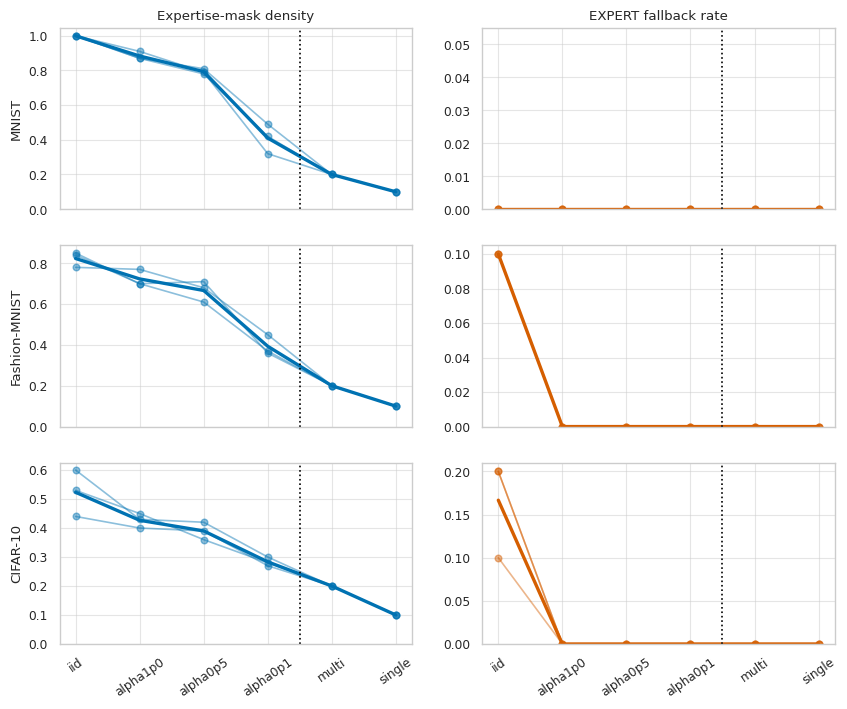

,dataset,regime,mean_density,sd_density,n_density,mean_fallback,sd_fallback,n_fallback,mean,sd,n
0,cifar,alpha0p1,0.283333,1.527525e-02,3,0.000000,0.000000e+00,3,2.833333,0.152753,3
1,cifar,alpha0p5,0.390000,3.000000e-02,3,0.000000,0.000000e+00,3,3.900000,0.300000,3
2,cifar,alpha1p0,0.426667,2.516611e-02,3,0.000000,0.000000e+00,3,4.266667,0.251661,3
3,cifar,iid,0.523333,8.020806e-02,3,0.166667,5.773503e-02,3,5.233333,0.802081,3
4,cifar,multi,0.200000,3.399350e-17,3,0.000000,0.000000e+00,3,2.000000,0.000000,3
5,cifar,single,0.100000,1.699675e-17,3,0.000000,0.000000e+00,3,1.000000,0.000000,3
6,fmnist,alpha0p1,0.393333,4.932883e-02,3,0.000000,0.000000e+00,3,3.933333,0.493288,3
7,fmnist,alpha0p5,0.666667,5.131601e-02,3,0.000000,0.000000e+00,3,6.666667,0.513160,3
8,fmnist,alpha1p0,0.723333,4.041452e-02,3,0.000000,0.000000e+00,3,7.233333,0.404145,3
9,fmnist,iid,0.823333,3.785939e-02,3,0.100000,1.699675e-17,3,8.233333,0.378594,3


**IID classes without an expert (read from CSV):**

,dataset,seed,classes_without_expert
18,fmnist,42,[6]
24,fmnist,43,[6]
30,fmnist,44,[6]
36,cifar,42,"[2, 3]"
42,cifar,43,"[2, 3]"
48,cifar,44,[3]


In [3]:
expert_rows = main.loc[main.method.eq('expert_prob'), ['dataset','regime','seed','fallback_rate','mean_selected_teachers']].merge(conditions, on=['dataset','regime','seed'], validate='one_to_one')
coverage = summary(expert_rows, 'M_density', ['dataset','regime']).merge(summary(expert_rows, 'fallback_rate', ['dataset','regime']), on=['dataset','regime'], suffixes=('_density','_fallback'))
coverage = coverage.merge(summary(expert_rows, 'mean_selected_teachers', ['dataset','regime']), on=['dataset','regime'])
coverage.to_csv(TAB / 'table_coverage_fallback.csv', index=False)
fig, axes = plt.subplots(3, 2, figsize=(10, 8), sharex=True)
for i, dataset in enumerate(DATASETS):
    d = expert_rows.loc[expert_rows.dataset.eq(dataset)]
    for seed, s in d.groupby('seed'):
        s = s.set_index('regime').reindex(REGIMES).reset_index()
        axes[i,0].plot(REGIMES, s.M_density, marker='o', alpha=.45, color='#0072B2')
        axes[i,1].plot(REGIMES, s.fallback_rate, marker='o', alpha=.45, color='#D55E00')
    mean_d = d.groupby('regime').M_density.mean().reindex(REGIMES); mean_f = d.groupby('regime').fallback_rate.mean().reindex(REGIMES)
    axes[i,0].plot(REGIMES, mean_d, color='#0072B2', lw=2.4); axes[i,1].plot(REGIMES, mean_f, color='#D55E00', lw=2.4)
    axes[i,0].set_ylabel(DATASET_LABEL[dataset]); axes[i,0].axvline(3.5, ls=':', color='black'); axes[i,1].axvline(3.5, ls=':', color='black')
axes[0,0].set_title('Expertise-mask density'); axes[0,1].set_title('EXPERT fallback rate')
for ax in axes.flat: ax.tick_params(axis='x', rotation=35); ax.set_ylim(bottom=0)
savefig('fig1_expertise_coverage'); plt.show()
display(coverage)
iid_missing = conditions.loc[(conditions.regime.eq('iid')) & conditions.classes_without_expert.ne('[]'), ['dataset','seed','classes_without_expert']]
display(Markdown('**IID classes without an expert (read from CSV):**')); display(iid_missing if len(iid_missing) else pd.DataFrame({'status':['none']}))


## 3. RQ1 — Who should contribute?

Absolute accuracy is restricted to logit-space methods; paired seed effects are the primary comparison.

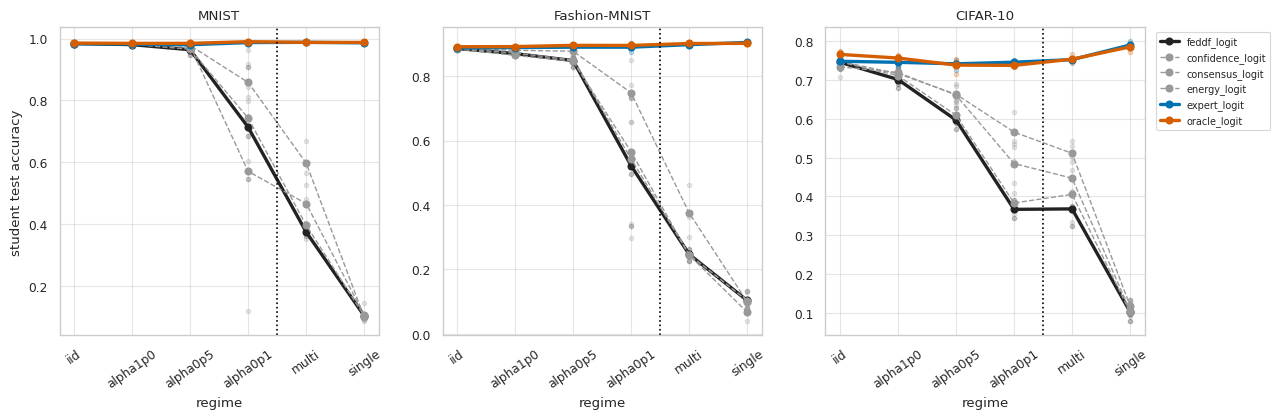

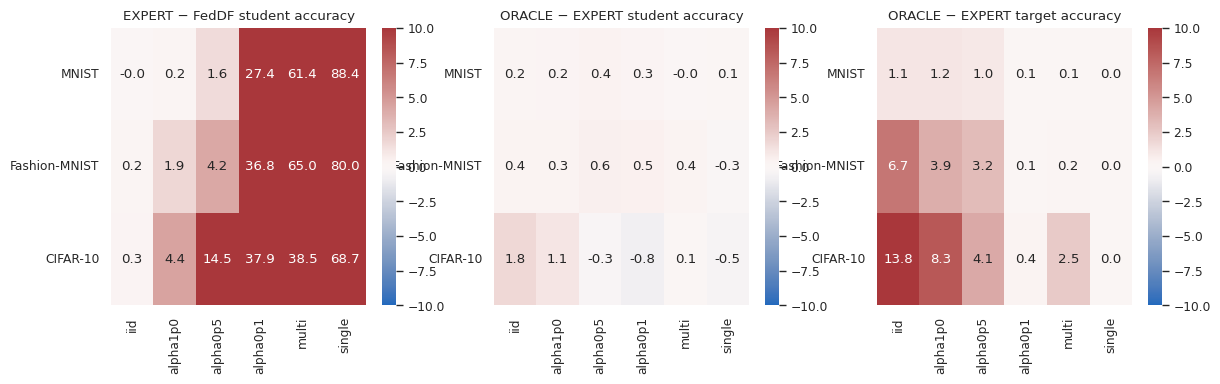

,dataset,regime,method,mean,sd,n,mean_selected_teachers,target_entropy,target_nll,student_test_nll,fallback_rate
0,cifar,alpha0p1,confidence_logit,9.742845,0.017098,3,10.000000,2.259568,2.028913,2.019029,0.000000
1,cifar,alpha0p1,consensus_logit,3.430100,0.222086,3,3.429767,1.963603,1.730435,3.512568,0.000033
2,cifar,alpha0p1,energy_logit,2.099587,0.285577,3,10.000000,1.807700,1.933224,5.593728,0.000000
3,cifar,alpha0p1,feddf_logit,10.000000,0.000000,3,10.000000,2.263531,2.060135,2.060523,0.000000
4,cifar,alpha0p5,confidence_logit,9.696719,0.029501,3,10.000000,2.222670,1.782357,1.189161,0.000000
5,cifar,alpha0p5,consensus_logit,5.296833,0.079035,3,5.296500,2.160139,1.614448,1.269580,0.000033
6,cifar,alpha0p5,energy_logit,2.562964,0.373107,3,10.000000,2.045565,1.480707,1.483663,0.000000
7,cifar,alpha0p5,feddf_logit,10.000000,0.000000,3,10.000000,2.229774,1.812374,1.183654,0.000000
8,cifar,alpha1p0,confidence_logit,9.703389,0.021199,3,10.000000,2.198963,1.667443,0.837005,0.000000
9,cifar,alpha1p0,consensus_logit,6.232600,0.158004,3,6.232600,2.168997,1.573859,0.883794,0.000000


In [4]:
rq1 = main.loc[main.method.isin(LOGIT_METHODS)].copy()
main_table = summary(rq1, 'student_test_accuracy', ['dataset','regime','method'])
main_table.to_csv(TAB / 'table_main_rq1_accuracy.csv', index=False)
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, dataset in zip(axes, DATASETS):
    d = rq1.loc[rq1.dataset.eq(dataset)]
    for method in LOGIT_METHODS:
        s = summary(d.loc[d.method.eq(method)], 'student_test_accuracy', ['regime']).set_index('regime').reindex(REGIMES)
        primary = method in PRIMARY
        ax.plot(REGIMES, s['mean'], marker='o', lw=2.4 if primary else 1.0, ls='-' if primary else '--', color=PALETTE[method], label=method)
        raw = d.loc[d.method.eq(method)]
        ax.scatter(raw.regime.map({r:i for i,r in enumerate(REGIMES)}), raw.student_test_accuracy, s=10, alpha=.25, color=PALETTE[method])
    ax.axvline(3.5, ls=':', color='black'); ax.set_title(DATASET_LABEL[dataset]); ax.set_xlabel('regime'); ax.tick_params(axis='x', rotation=35)
axes[0].set_ylabel('student test accuracy'); axes[-1].legend(fontsize=7, bbox_to_anchor=(1.02,1), loc='upper left')
savefig('fig2_rq1_student_accuracy'); plt.show()
effects = pd.concat([paired(main, method, 'feddf_logit') for method in LOGIT_METHODS if method != 'feddf_logit'], ignore_index=True)
effect_table = effects.groupby(['dataset','regime','contrast']).delta.agg(mean='mean', sd=lambda x:x.std(ddof=1), seed_values=lambda x: json.dumps([round(v,5) for v in x]), sign_consistency=lambda x:int(abs(np.sign(x).sum()))).reset_index()
effect_table.to_csv(OUT / 'paired_effects.csv', index=False); effect_table.to_csv(TAB / 'table_paired_effects_rq1.csv', index=False)
eo_acc = paired(main, 'oracle_logit', 'expert_logit')
eo_target = paired(main, 'oracle_logit', 'expert_logit', 'target_accuracy')
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
heat(axes[0], summary(effects.loc[effects.contrast.eq('expert_logit - feddf_logit')], 'delta', ['dataset','regime']), 'EXPERT − FedDF student accuracy')
heat(axes[1], summary(eo_acc, 'delta', ['dataset','regime']), 'ORACLE − EXPERT student accuracy')
heat(axes[2], summary(eo_target, 'delta', ['dataset','regime']), 'ORACLE − EXPERT target accuracy')
savefig('fig3_paired_effects_oracle_gap'); plt.show()
control_metrics = summary(main.loc[main.method.isin(['feddf_logit','confidence_logit','consensus_logit','energy_logit'])], 'effective_teachers', ['dataset','regime','method'])
for metric in ['mean_selected_teachers','target_entropy','target_nll','student_test_nll','fallback_rate']:
    control_metrics = control_metrics.merge(summary(main.loc[main.method.isin(['feddf_logit','confidence_logit','consensus_logit','energy_logit'])], metric, ['dataset','regime','method'])[['dataset','regime','method','mean']].rename(columns={'mean':metric}), on=['dataset','regime','method'])
control_metrics.to_csv(TAB / 'table_prediction_only_controls.csv', index=False)
display(control_metrics.head(12))


## 4–5. RQ2 and mechanism: what/how should experts contribute?

SR is compared directly with EXPERT-prob. Target quality is diagnostic, not proof of student transfer utility.

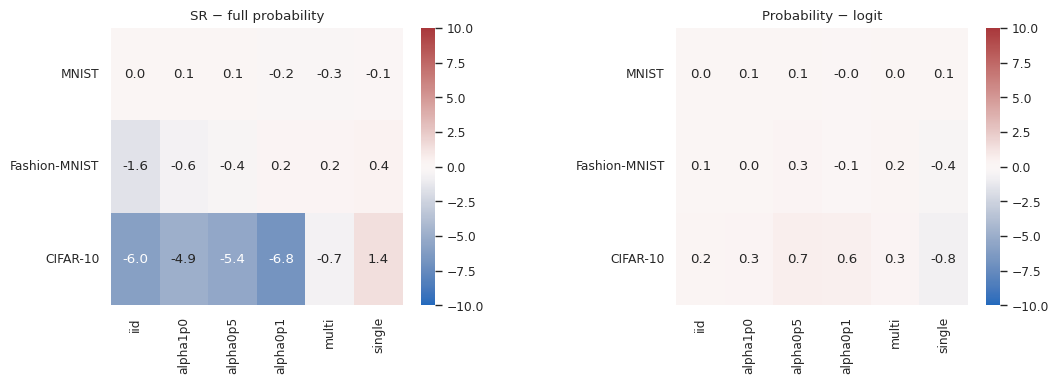

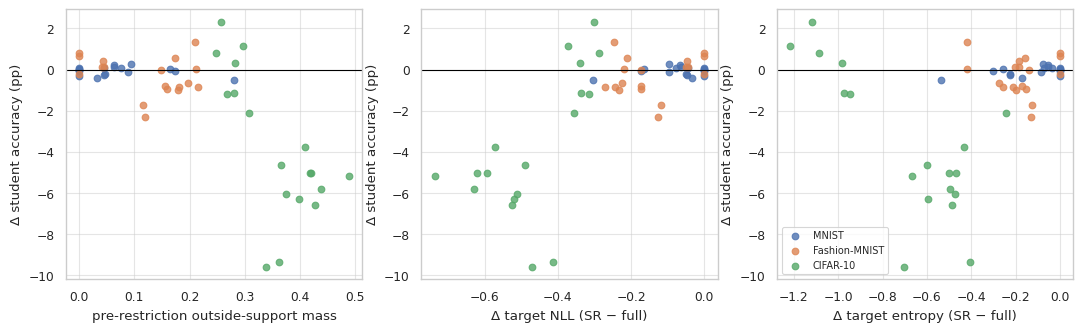

In [5]:
prob_logit = paired(main, 'expert_prob', 'expert_logit')
sr = paired(main, 'expert_prob_sr', 'expert_prob')
oracle_space = paired(main, 'oracle_prob', 'oracle_logit')
ablation = pd.concat([prob_logit, sr, oracle_space], ignore_index=True)
ablation_table = ablation.groupby(['dataset','regime','contrast']).delta.agg(mean='mean', sd=lambda x:x.std(ddof=1), seed_values=lambda x:json.dumps([round(v,5) for v in x]), sign_consistency=lambda x:int(abs(np.sign(x).sum()))).reset_index()
ablation_table['interpretation'] = [practical(v, None) for v in ablation_table['mean']]
ablation_table.to_csv(TAB / 'table_expert_ablation.csv', index=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
heat(axes[0], summary(sr, 'delta', ['dataset','regime']), 'SR − full probability')
heat(axes[1], summary(prob_logit, 'delta', ['dataset','regime']), 'Probability − logit')
fig.subplots_adjust(wspace=0.55)
savefig('fig4_expert_ablation'); plt.show()
target_student = pd.DataFrame()
for metric in ['target_accuracy','target_nll','target_entropy']:
    d = paired(main, 'expert_prob_sr', 'expert_prob', metric)[['dataset','regime','seed','delta']].rename(columns={'delta':f'delta_{metric}'})
    target_student = d if target_student.empty else target_student.merge(d, on=['dataset','regime','seed'])
target_student = target_student.merge(sr[['dataset','regime','seed','delta']].rename(columns={'delta':'delta_student_accuracy'}), on=['dataset','regime','seed'])
target_student.to_csv(TAB / 'table_target_student_disagreement.csv', index=False)
mechanism = target_student.merge(main.loc[main.method.eq('expert_prob'), ['dataset','regime','seed','pre_restriction_outside_support_mass','mean_selected_teachers']], on=['dataset','regime','seed'])
mechanism.to_csv(TAB / 'table_mechanism.csv', index=False)
corr = []
for label, d in [('overall', mechanism), *[(x, mechanism.loc[mechanism.dataset.eq(x)]) for x in DATASETS]]:
    corr.append({'scope':label, 'outside_mass_vs_SR':d.pre_restriction_outside_support_mass.corr(d.delta_student_accuracy), 'target_nll_change_vs_SR':d.delta_target_nll.corr(d.delta_student_accuracy), 'entropy_change_vs_SR':d.delta_target_entropy.corr(d.delta_student_accuracy), 'n':len(d)})
pd.DataFrame(corr).to_csv(TAB / 'table_mechanism_associations.csv', index=False)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for dataset in DATASETS:
    d = mechanism.loc[mechanism.dataset.eq(dataset)]
    axes[0].scatter(d.pre_restriction_outside_support_mass, d.delta_student_accuracy*100, label=DATASET_LABEL[dataset], alpha=.8)
    axes[1].scatter(d.delta_target_nll, d.delta_student_accuracy*100, label=DATASET_LABEL[dataset], alpha=.8)
    axes[2].scatter(d.delta_target_entropy, d.delta_student_accuracy*100, label=DATASET_LABEL[dataset], alpha=.8)
for ax, xlab in zip(axes, ['pre-restriction outside-support mass', 'Δ target NLL (SR − full)', 'Δ target entropy (SR − full)']):
    ax.axhline(0,color='black',lw=.8); ax.set(xlabel=xlab, ylabel='Δ student accuracy (pp)')
axes[-1].legend(fontsize=7); savefig('fig5_support_restriction_mechanism'); plt.show()
single_control = main.loc[(main.regime.eq('single')) & main.method.isin(['expert_prob','expert_prob_sr'])][['dataset','seed','method','target_entropy','target_nll','student_test_accuracy','pre_restriction_outside_support_mass']]
single_control.to_csv(TAB / 'table_single_structural_control.csv', index=False)


## 6. Temperature sensitivity

The section is deliberately conditional: `T=8` remains primary and no partial temperature conclusion is drawn.

In [6]:
temps, temp_regs, temp_methods = [1.0,4.0,8.0], ['iid','alpha0p1','single'], ['expert_prob','expert_prob_sr']
expected = pd.DataFrame(product(['cifar'], temp_regs, SEEDS, temp_methods, temps), columns=key)
available = results.merge(expected, on=key, how='inner')
missing_temp = expected.merge(available[key], on=key, how='left', indicator=True).query('_merge == "left_only"').drop(columns='_merge')
temperature_status = pd.DataFrame([{'expected_rows':len(expected), 'available_rows':len(available), 'missing_rows':len(missing_temp), 'status':'complete' if len(missing_temp)==0 else 'PENDING — incomplete sensitivity grid'}])
temperature_status.to_csv(TAB / 'table_temperature_availability.csv', index=False)
display(temperature_status)
if len(missing_temp):
    missing_temp.to_csv(TAB / 'table_temperature_missing_cells.csv', index=False)
    display(Markdown('**Pending:** the following cells are absent; no temperature-effect figure is generated.'))
    display(missing_temp)
else:
    temp_sr = paired(available, 'expert_prob_sr', 'expert_prob')
    temp_summary = summary(temp_sr, 'delta', ['regime','temperature'])
    temp_summary.to_csv(TAB / 'table_temperature_sensitivity.csv', index=False)
    fig, ax = plt.subplots(figsize=(6,3.5))
    sns.lineplot(data=temp_summary, x='temperature', y='mean', hue='regime', marker='o', ax=ax)
    ax.axhline(0,color='black',lw=.8); ax.set(ylabel='Δ SR − full student accuracy', title='CIFAR-10 temperature sensitivity')
    savefig('fig4b_temperature_sensitivity'); plt.show()


,expected_rows,available_rows,missing_rows,status
0,54,24,30,PENDING — incomplete sensitivity grid


**Pending:** the following cells are absent; no temperature-effect figure is generated.

,dataset,regime,seed,method,temperature
6,cifar,iid,43,expert_prob,1.0
7,cifar,iid,43,expert_prob,4.0
9,cifar,iid,43,expert_prob_sr,1.0
10,cifar,iid,43,expert_prob_sr,4.0
12,cifar,iid,44,expert_prob,1.0
13,cifar,iid,44,expert_prob,4.0
15,cifar,iid,44,expert_prob_sr,1.0
16,cifar,iid,44,expert_prob_sr,4.0
19,cifar,alpha0p1,42,expert_prob,4.0
22,cifar,alpha0p1,42,expert_prob_sr,4.0


## 7–9. Statistical treatment, claim ledger, and exported artifacts

Seed is the replicate within each dataset–regime. Values below are descriptive mean ± sample SD with paired seed deltas; no significance tests, bootstrap intervals, pooled inferential tests, or global method ranking are used.

In [7]:
h1 = summary(effects.loc[effects.contrast.eq('expert_logit - feddf_logit')], 'delta', ['dataset','regime'])
h2 = summary(eo_acc, 'delta', ['dataset','regime'])
ledger = pd.DataFrame([
 {'observation':'EXPERT advantage vs FedDF', 'compatible_interpretation':'selection can help under specialization', 'paper_claim':'Report regime- and dataset-specific paired effects', 'does_not_demonstrate':'uniform monotonic heterogeneity effect', 'support':'Fig. 3; paired-effects table', 'status':'mixed'},
 {'observation':'EXPERT–ORACLE gap', 'compatible_interpretation':'EXPERT may retain much of label-consistent routing information', 'paper_claim':'Describe observed paired gap only', 'does_not_demonstrate':'equivalence or ORACLE upper bound', 'support':'Fig. 3', 'status':'mixed'},
 {'observation':'Logit vs probability', 'compatible_interpretation':'aggregation space can affect transfer', 'paper_claim':'Use ≥1 pp practical threshold', 'does_not_demonstrate':'calibration mechanism', 'support':'Fig. 4', 'status':'mixed'},
 {'observation':'Full support vs SR', 'compatible_interpretation':'restriction can trade label consistency for dark knowledge', 'paper_claim':'Separate target and student effects', 'does_not_demonstrate':'contamination removal from target NLL alone', 'support':'Figs. 4–5', 'status':'mixed'},
 {'observation':'single structural control', 'compatible_interpretation':'removes much interclass dark knowledge', 'paper_claim':'Treat separately from Dirichlet continuum', 'does_not_demonstrate':'general non-IID summary', 'support':'single-control table', 'status':'supported'},
 {'observation':'Temperature robustness', 'compatible_interpretation':'requires the complete predefined sensitivity grid', 'paper_claim':'None until grid completes', 'does_not_demonstrate':'T=8 robustness', 'support':'temperature availability table', 'status':'pending'},
 {'observation':'Prediction-only controls', 'compatible_interpretation':'concentration/selection diagnostics are descriptive', 'paper_claim':'Report as secondary controls', 'does_not_demonstrate':'a published SOTA comparison', 'support':'control diagnostics table', 'status':'supported'},
])
ledger.to_csv(OUT / 'analysis_summary.csv', index=False); ledger.to_csv(TAB / 'table_claim_ledger.csv', index=False)
taxonomy = pd.DataFrame([
 ['feddf_logit','external comparator','all teachers; no proxy labels','logit mean'], ['confidence_logit','internal control','teacher logits','MSP-weighted logits'], ['consensus_logit','internal control','teacher logits','soft-vote selected logits'], ['energy_logit','internal control','teacher logits','energy-weighted logits'], ['expert_logit','informed','proxy labels + holdout M','selected logits'], ['oracle_logit','informed control','proxy labels','correct-teacher logits'], ['expert_prob','ablation','proxy labels + holdout M','selected probabilities'], ['expert_prob_sr','ablation','proxy labels + holdout M','support-restricted probabilities'], ['oracle_prob','ablation control','proxy labels','correct-teacher probabilities']], columns=['method','category','information required','operator'])
taxonomy.to_csv(TAB / 'table_method_taxonomy.csv', index=False)
display(ledger)
print('Exported figures:', sorted(p.name for p in FIG.glob('*.pdf')))
print('Exported tables:', sorted(p.name for p in TAB.glob('*.csv')))


,observation,compatible_interpretation,paper_claim,does_not_demonstrate,support,status
0,EXPERT advantage vs FedDF,selection can help under specialization,Report regime- and dataset-specific paired eff...,uniform monotonic heterogeneity effect,Fig. 3; paired-effects table,mixed
1,EXPERT–ORACLE gap,EXPERT may retain much of label-consistent rou...,Describe observed paired gap only,equivalence or ORACLE upper bound,Fig. 3,mixed
2,Logit vs probability,aggregation space can affect transfer,Use ≥1 pp practical threshold,calibration mechanism,Fig. 4,mixed
3,Full support vs SR,restriction can trade label consistency for da...,Separate target and student effects,contamination removal from target NLL alone,Figs. 4–5,mixed
4,single structural control,removes much interclass dark knowledge,Treat separately from Dirichlet continuum,general non-IID summary,single-control table,supported
5,Temperature robustness,requires the complete predefined sensitivity grid,None until grid completes,T=8 robustness,temperature availability table,pending
6,Prediction-only controls,concentration/selection diagnostics are descri...,Report as secondary controls,a published SOTA comparison,control diagnostics table,supported


Exported figures: ['fig1_expertise_coverage.pdf', 'fig2_rq1_student_accuracy.pdf', 'fig3_paired_effects_oracle_gap.pdf', 'fig4_expert_ablation.pdf', 'fig5_support_restriction_mechanism.pdf']
Exported tables: ['table_claim_ledger.csv', 'table_coverage_fallback.csv', 'table_expert_ablation.csv', 'table_integrity.csv', 'table_main_rq1_accuracy.csv', 'table_mechanism.csv', 'table_mechanism_associations.csv', 'table_method_taxonomy.csv', 'table_paired_effects_rq1.csv', 'table_prediction_only_controls.csv', 'table_single_structural_control.csv', 'table_target_student_disagreement.csv', 'table_temperature_availability.csv', 'table_temperature_missing_cells.csv']
